# 🏡 House Prices Data Cleaning, Preprocessing & Feature Engineering

## 📌 Project Overview

This notebook demonstrates a complete data preprocessing workflow using the **House Prices: Advanced Regression Techniques** dataset from Kaggle.

The objective is to transform raw housing data into a clean, machine learning-ready dataset by applying industry-standard preprocessing techniques.

---

## 🎯 Objectives

- Perform comprehensive data quality assessment
- Handle missing values using multiple imputation techniques
- Remove duplicate and invalid records
- Detect and treat outliers
- Encode categorical variables
- Scale numerical features
- Engineer meaningful features
- Prevent data leakage
- Create reusable Scikit-Learn preprocessing pipelines
- Generate a clean dataset for machine learning models

---

## 📚 Topics Covered

- Data Quality Assessment
- Missing Value Treatment
- Duplicate Detection
- Data Type Conversion
- Outlier Detection & Treatment
- Categorical Encoding
- Numerical Scaling
- Feature Engineering
- Data Splitting
- Data Leakage
- Scikit-Learn Pipelines
- Reusable Preprocessing Functions

---

**Dataset**

- House Prices: Advanced Regression Techniques

**Problem Type**

Regression

**Target Variable**

`SalePrice`

## Import Libraries

In [2]:
# ==========================================================
# Block 2 - Import Required Libraries
# ==========================================================


# -------------------------
# Standard Libraries
# -------------------------

import os
import sys
import warnings
import importlib

warnings.filterwarnings("ignore")



# -------------------------
# Add Project Root to Path
# -------------------------

PROJECT_ROOT = os.path.abspath("..")


if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


print(f"Project Root: {PROJECT_ROOT}")



# -------------------------
# Data Manipulation
# -------------------------

import numpy as np
import pandas as pd



# -------------------------
# Visualization
# -------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid"
)


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

pd.set_option(
    "display.width",
    None
)



# -------------------------
# Machine Learning
# -------------------------

from sklearn.model_selection import (
    train_test_split
)



# ==========================================================
# Reload Source Modules
# ==========================================================

import src.utils
import src.preprocessing


importlib.reload(
    src.utils
)

importlib.reload(
    src.preprocessing
)



# Load pipeline only if it exists

try:

    import src.pipeline

    importlib.reload(
        src.pipeline
    )

    from src.pipeline import *

    print("Pipeline module loaded")

except ModuleNotFoundError:

    print(
        "Pipeline module not created yet"
    )



# ==========================================================
# Import Project Functions
# ==========================================================

from src.utils import *

from src.preprocessing import *


print(
    "✅ All libraries imported successfully."
)

Project Root: c:\Users\abuba\Downloads\ML-Projects\Day-3
Pipeline module loaded
✅ All libraries imported successfully.


## Load the Dataset

In [3]:
TRAIN_PATH = "../datasets/house-prices/train.csv"
TEST_PATH = "../datasets/house-prices/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("=" * 60)
print(f"Training Dataset Shape : {train_df.shape}")
print(f"Testing Dataset Shape  : {test_df.shape}")
print("=" * 60)

display(train_df.head())

Training Dataset Shape : (1460, 81)
Testing Dataset Shape  : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Dataset Overview

This block gives you a high-level understanding of the dataset before any preprocessing.

In [4]:
print("=" * 60)
print("HOUSE PRICES DATASET OVERVIEW")
print("=" * 60)

# Basic Information
print(f"\nDataset Shape : {train_df.shape}")
print(f"Rows          : {train_df.shape[0]}")
print(f"Columns       : {train_df.shape[1]}")

# Display First Five Rows
display(train_df.head())

# Dataset Information
print("\nDataset Information")
train_df.info()

# Statistical Summary (Numerical Features)
print("\nNumerical Feature Summary")
display(train_df.describe())

# Statistical Summary (Categorical Features)
print("\nCategorical Feature Summary")
display(train_df.describe(include="object"))

# Data Types
print("\nData Types")
display(train_df.dtypes.value_counts())

# Target Variable
print("\nTarget Variable")
print(train_df["SalePrice"].describe())

HOUSE PRICES DATASET OVERVIEW

Dataset Shape : (1460, 81)
Rows          : 1460
Columns       : 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



Categorical Feature Summary


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198



Data Types


str        43
int64      35
float64     3
Name: count, dtype: int64


Target Variable
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## Data Quality Assessment

Understand the quality of the dataset before cleaning it.

In [5]:
dataset_summary(train_df, target="SalePrice")
print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

# Dataset Shape
print(f"\nDataset Shape: {train_df.shape}")

# Total Missing Values
missing_values = train_df.isnull().sum().sum()
print(f"\nTotal Missing Values: {missing_values}")

# Duplicate Records
duplicates = train_df.duplicated().sum()
print(f"Duplicate Records: {duplicates}")

# Data Types
print("\nData Types Summary")
display(train_df.dtypes.value_counts())

# Memory Usage
memory = train_df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory Usage: {memory:.2f} MB")

# Target Variable
print("\nTarget Variable")
print(train_df["SalePrice"].describe())



DATA QUALITY ASSESSMENT

Dataset Shape: (1460, 81)

Total Missing Values: 7829
Duplicate Records: 0

Data Types Summary


str        43
int64      35
float64     3
Name: count, dtype: int64


Memory Usage: 3.43 MB

Target Variable (SalePrice)
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
DATA QUALITY ASSESSMENT

Dataset Shape: (1460, 81)



Total Missing Values: 7829
Duplicate Records: 0

Data Types Summary


str        43
int64      35
float64     3
Name: count, dtype: int64


Memory Usage: 3.43 MB

Target Variable
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## Missing Value Summary

In [6]:
missing = (
    train_df.isnull()
            .sum()
            .sort_values(ascending=False)
            .to_frame(name="Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(train_df) * 100
).round(2)

missing = missing[missing["Missing Values"] > 0]

display(missing)

,Missing Values,Percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


## Missing Value Analysis

Before treating missing values, classify them.

In [7]:
missing = (
    train_df.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(train_df) * 100
).round(2)

missing = missing[missing["Missing Values"] > 0]

display(missing)

,Missing Values,Percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


Save the table

In [8]:
missing.to_csv("../reports/house_missing_summary.csv")

## Missing Value Visualization

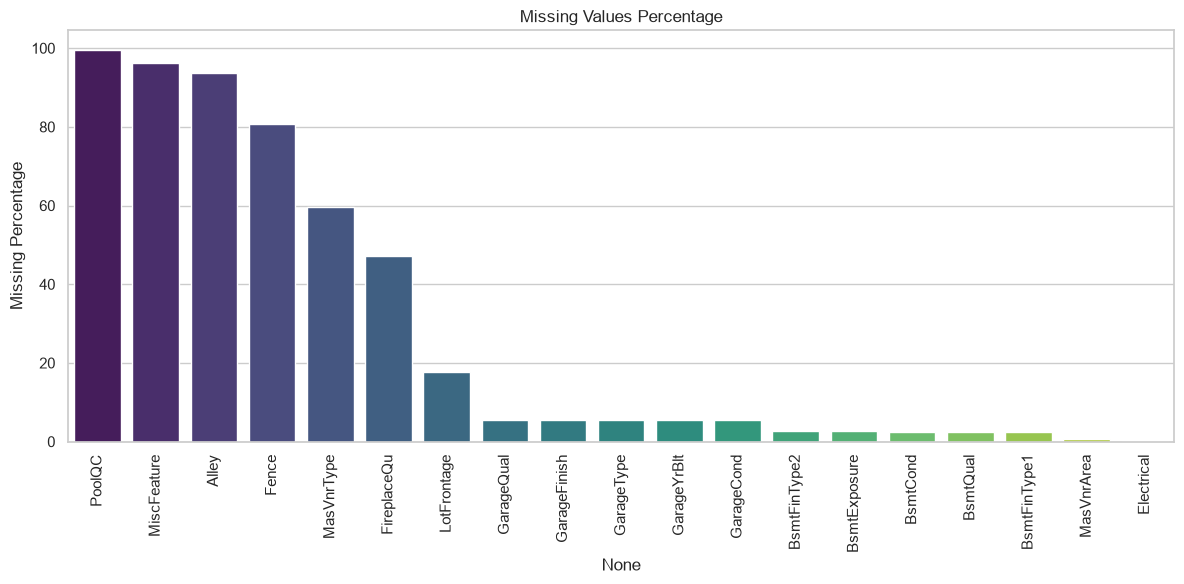

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing.index,
    y=missing["Percentage"],
    palette="viridis"
)

plt.xticks(rotation=90)
plt.ylabel("Missing Percentage")
plt.title("Missing Values Percentage")

plt.tight_layout()

plt.savefig(
    "../images/house_price/missing_values_percentage.png",
    dpi=300
)

plt.show()

## Missing Value Matrix

<Figure size 1400x600 with 0 Axes>

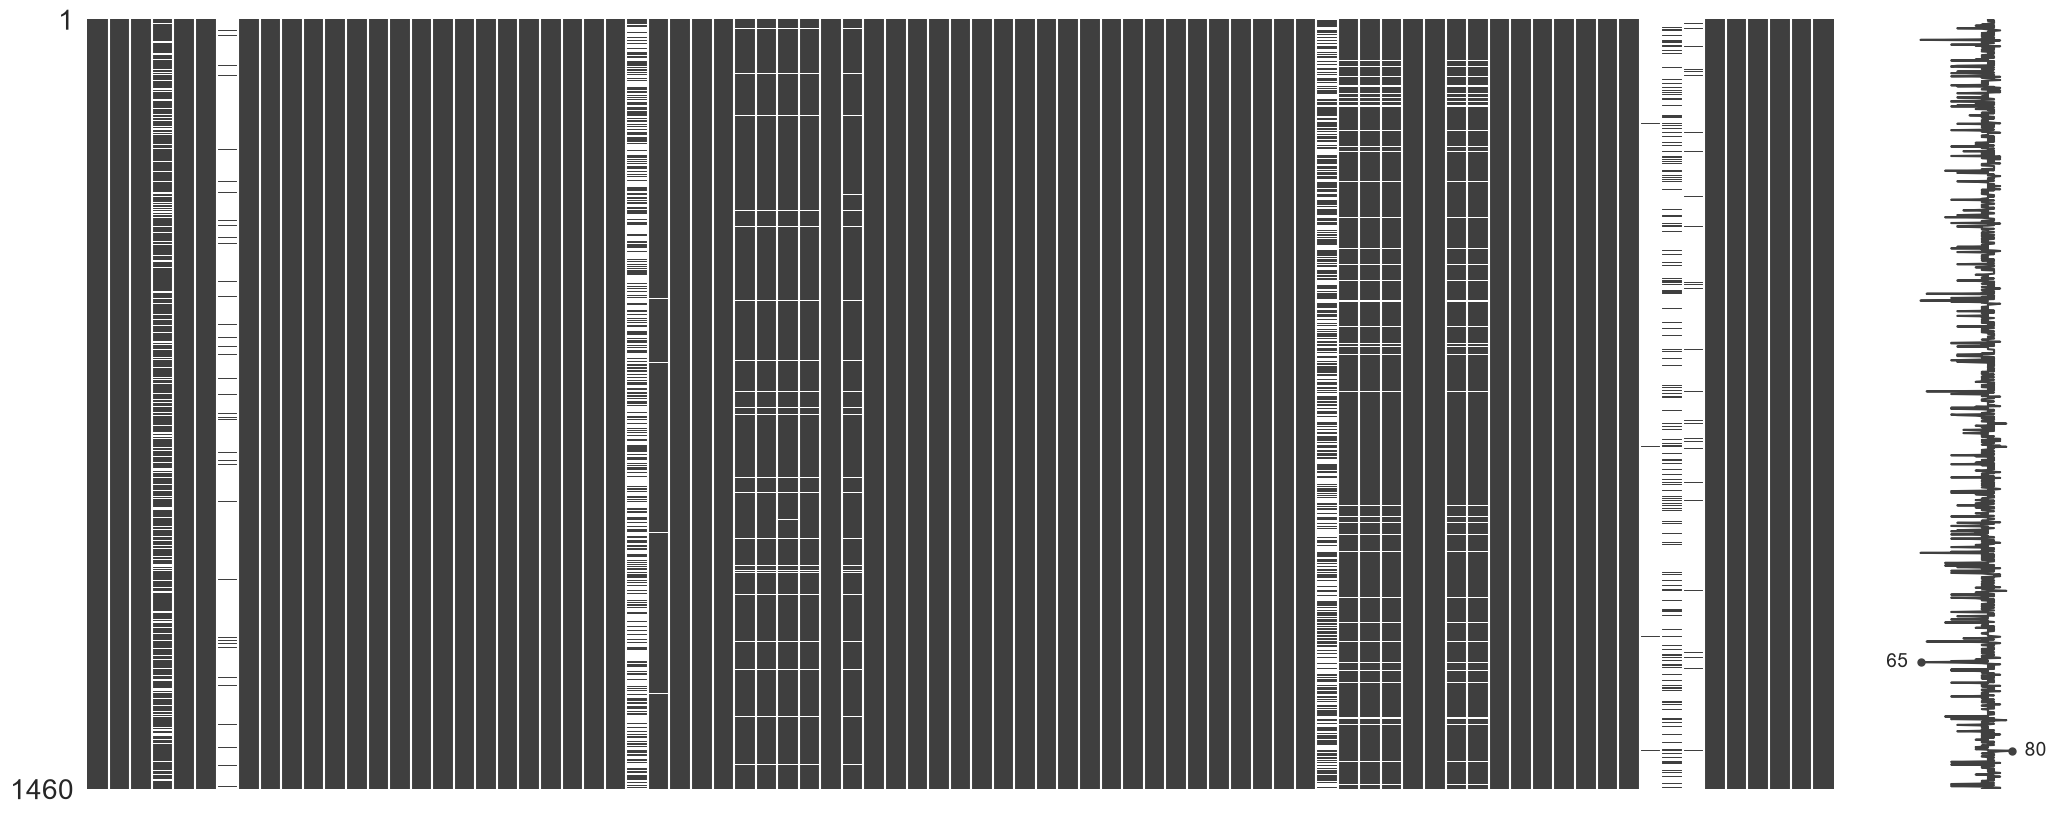

In [10]:
plt.figure(figsize=(14,6))

msno.matrix(train_df)

plt.savefig(
    "../images/house_price/missing_matrix.png",
    dpi=300
)

plt.show()

# Missing Value Treatment Strategy

Based on the missing value analysis, different imputation techniques will be applied according to the percentage of missing values and the meaning of each feature.

| Feature Group | Strategy |
|---------------|----------|
| PoolQC, MiscFeature, Alley, Fence | Drop Columns |
| LotFrontage | Median Imputation |
| Electrical | Mode Imputation |
| Garage Features | Fill with "NoGarage" |
| Basement Features | Fill with "NoBasement" |
| MasVnrType | Fill with "None" |
| MasVnrArea | Fill with 0 |
| GarageYrBlt | Fill with 0 |

The selected strategy minimizes information loss while preserving the underlying characteristics of the dataset.

In [11]:
train_df = handle_missing_values(train_df)

train_df = clean_categories(train_df)

train_df = create_house_features(train_df)

In [12]:
train_df.shape

(1460, 81)

Remaining missing values

In [13]:
missing = (
    train_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

Series([], dtype: int64)

In [14]:
train_df[
    [
        "HouseAge",
        "TotalBathrooms",
        "TotalArea",
        "TotalPorchArea"
    ]
].head()

,HouseAge,TotalBathrooms,TotalArea,TotalPorchArea
0,5,3.5,2566,61
1,31,2.5,2524,0
2,7,3.5,2706,42
3,91,2.0,2473,307
4,8,3.5,3343,84


In [15]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              1460 non-null   int64  
 1   MSSubClass      1460 non-null   int64  
 2   MSZoning        1460 non-null   str    
 3   LotFrontage     1460 non-null   float64
 4   LotArea         1460 non-null   int64  
 5   Street          1460 non-null   str    
 6   LotShape        1460 non-null   str    
 7   LandContour     1460 non-null   str    
 8   Utilities       1460 non-null   str    
 9   LotConfig       1460 non-null   str    
 10  LandSlope       1460 non-null   str    
 11  Neighborhood    1460 non-null   str    
 12  Condition1      1460 non-null   str    
 13  Condition2      1460 non-null   str    
 14  BldgType        1460 non-null   str    
 15  HouseStyle      1460 non-null   str    
 16  OverallQual     1460 non-null   int64  
 17  OverallCond     1460 non-null   int64  
 18 

## Duplicate Records

In [16]:
duplicates = check_duplicates(train_df)

print(
    "Duplicate Rows:",
    duplicates
)

Duplicate Rows: 0


## Invalid Values

In [17]:
invalid_values = check_invalid_values(train_df)

invalid_values

{}

## Data Types Check

In [18]:
data_types = check_data_types(train_df)

data_types

Id                  int64
MSSubClass          int64
MSZoning              str
LotFrontage       float64
LotArea             int64
Street                str
LotShape              str
LandContour           str
Utilities             str
LotConfig             str
LandSlope             str
Neighborhood          str
Condition1            str
Condition2            str
BldgType              str
HouseStyle            str
OverallQual         int64
OverallCond         int64
YearBuilt           int64
YearRemodAdd        int64
RoofStyle             str
RoofMatl              str
Exterior1st           str
Exterior2nd           str
MasVnrType            str
MasVnrArea        float64
ExterQual             str
ExterCond             str
Foundation            str
BsmtQual              str
BsmtCond              str
BsmtExposure          str
BsmtFinType1          str
BsmtFinSF1          int64
BsmtFinType2          str
BsmtFinSF2          int64
BsmtUnfSF           int64
TotalBsmtSF         int64
Heating     

## Outlier Detection

In [19]:
saleprice_outliers = detect_outliers_iqr(
    train_df,
    "SalePrice"
)


print(
    "SalePrice IQR Outliers:",
    len(saleprice_outliers)
)

SalePrice IQR Outliers: 61


## Visualize Outliers

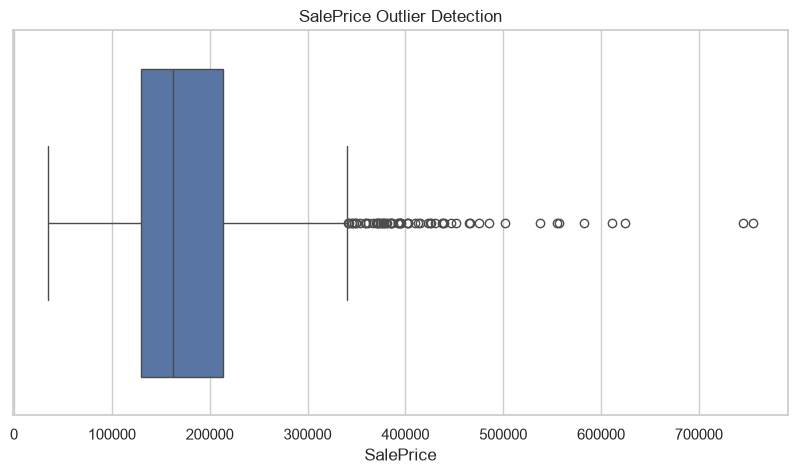

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=train_df["SalePrice"]
)

plt.title(
    "SalePrice Outlier Detection"
)

plt.savefig(
    "../images/house_price/saleprice_outliers.png",
    dpi=300
)

plt.show()

## Z-score Comparison

In [21]:
z_outliers = detect_outliers_zscore(
    train_df,
    "SalePrice"
)


print(
    "Z-score Outliers:",
    len(z_outliers)
)

Z-score Outliers: 22


## Outlier Treatment Comparison
Compare Removal vs Capping (Winsorization)

In [22]:
# Before

print(
    train_df["SalePrice"].describe()
)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [23]:
capped_df = cap_outliers(
    train_df,
    "SalePrice"
)

In [24]:
print(
    capped_df["SalePrice"].describe()
)

count      1460.000000
mean     177331.526370
std       67205.835915
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      340037.500000
Name: SalePrice, dtype: float64


## Outlier Capping Results

The SalePrice feature contained extreme values, with the highest property price reaching 755,000. These extreme observations increased the variance and caused the target distribution to become highly right-skewed.

The IQR-based Winsorization technique was applied to reduce the impact of outliers while preserving all training records.

### Results:

Before Capping:
- Maximum SalePrice: 755,000
- Number of records: 1460

After Capping:
- Maximum SalePrice: 340,037.5
- Number of records: 1460

The capping approach successfully reduced the influence of extreme values without losing important data points, making the dataset more suitable for machine learning models.

In [25]:
import src.pipeline
importlib.reload(src.pipeline)

from src.pipeline import *

In [26]:
from src.pipeline import create_preprocessor

In [27]:
preprocessor = create_preprocessor(
    train_df
)

In [28]:
X = preprocessor.fit_transform(
    train_df
)


print(
    X.shape
)

(1460, 291)


Raw Data
   |
   |
preprocessing.py
   |
   |
Clean Features
   |
   |
pipeline.py
   |
   |
Encoded + Scaled Data
   |
   |
Model Training

## Data Splitting & Data Leakage Prevention

In [30]:
#Separate Features and Target

X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1460, 80)
Target Shape: (1460,)


(The exact number of features depends on whether you kept or dropped certain columns.)

## Train/Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (1168, 80)
Testing Shape  : (292, 80)


# Data Splitting Strategy

The dataset was divided into training and testing sets before fitting any preprocessing transformers.

This prevents **data leakage**, where information from the test set unintentionally influences preprocessing steps such as imputation, scaling, or encoding.

Only the training data is used to fit preprocessing pipelines, while the same fitted transformers are applied to the test data.

In [32]:
## Fit the Pipeline Correctly
preprocessor = create_preprocessor(X_train)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape :", X_test_processed.shape)

Processed Train Shape: (1168, 288)
Processed Test Shape : (292, 288)


## Leakage Demonstration

In [33]:
#Data Leakage Example

print("❌ Incorrect Approach")

print(
    "Fitting preprocessing on the complete dataset "
    "before splitting causes data leakage."
)

print()

print("✅ Correct Approach")

print(
    "Split the dataset first, then fit preprocessing "
    "only on the training set."
)

❌ Incorrect Approach
Fitting preprocessing on the complete dataset before splitting causes data leakage.

✅ Correct Approach
Split the dataset first, then fit preprocessing only on the training set.


In [34]:
print(type(X_train_processed))
print(type(X_test_processed))

print(X_train_processed.shape)
print(X_test_processed.shape)

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>
(1168, 288)
(292, 288)


# Scikit-Learn Preprocessing Pipeline

A reusable Scikit-Learn preprocessing pipeline was implemented using `Pipeline` and `ColumnTransformer`.

The pipeline performs the following operations:

- **Numerical Features**
  - Median imputation
  - Standard scaling

- **Categorical Features**
  - Most frequent imputation
  - One-Hot Encoding

The preprocessing pipeline was fitted only on the training data and then applied to the testing data. This approach prevents data leakage and ensures that the model is evaluated on unseen data.

### Pipeline Results

- Training Samples: **1168**
- Testing Samples: **292**
- Features After Encoding: **288**

The transformed datasets are stored as sparse matrices to optimize memory usage after one-hot encoding.